# Índice de Aridez (UNEP) anual a partir de mapas mensuales de TerraClimate
Calcula, para cada año calendario completo, **IA = ΣPPT(12 meses) / ΣETP(12 meses)** con los archivos `ppt_<año>_<mes>.tif` y `etp_<año>_<mes>.tif` de la descarga mensual.

| Clase UNEP | Rango de IA |
|---|---|
| Hiperárida | < 0.05 |
| Árida | 0.05 – 0.20 |
| Semiárida | 0.20 – 0.50 |
| Subhúmeda seca | 0.50 – 0.65 |
| Húmeda | > 0.65 |

### Genera:
- **Malla original (4 km)**, recortada con la máscara: `PPT_anual`, `ETP_anual` e `IA_anual` por año, más `mascara_4km.tif`.
- **Promedio multianual:** `IA_promedio` (promedio de los IA anuales de todos los años).
- **(Opcional) 1 km**, con el flujo del script de QGIS (fill → reproyección UTM 13N → corte), para los mapas finales, y **vectores** con clases y colores de todos los años.

Solo se procesan años con los **12 meses** de PPT y de ETP. Si se descargaron con `APLICAR_ESCALA = True`, ya están en mm.

In [ ]:
# Instalar librerias (solo la primera vez)
# !pip install rasterio geopandas ipywidgets

In [1]:
import os
import re
import glob

# En Windows, PostgreSQL/PostGIS suelen definir PROJ_LIB/PROJ_DATA apuntando a SU proj.db,
# incompatible con el de rasterio (error "DATABASE.LAYOUT.VERSION.MINOR"). Se quitan ANTES de
# importar rasterio/geopandas y se usa la base de datos de proyecciones que trae rasterio.
for _v in ("PROJ_LIB", "PROJ_DATA"):
    os.environ.pop(_v, None)

import numpy as np
import rasterio
_proj_rasterio = os.path.join(os.path.dirname(rasterio.__file__), "proj_data")
if os.path.isdir(_proj_rasterio):
    os.environ["PROJ_DATA"] = _proj_rasterio
    os.environ["PROJ_LIB"] = _proj_rasterio
from rasterio.fill import fillnodata
from rasterio.features import geometry_mask
from rasterio.warp import calculate_default_transform, reproject, Resampling
from rasterio.transform import array_bounds
from rasterio.mask import mask as rio_mask
from rasterio.io import MemoryFile
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.patches import Patch

import warnings
warnings.filterwarnings('ignore')

### Configuración
- `ESCALA`: factor que se aplica al leer. Con `1.0` en ambas se asume que los archivos ya están en **mm** (descarga con `APLICAR_ESCALA = True`). Si se descargaron crudos usar `"etp": 0.1`. La celda de verificación lo confirma.
- `RUTA_MASCARA`: el `.shp` de Sinaloa. Si es `None`, solo se descartan los píxeles sin dato (mar, con ETP = 0).
- `ALL_TOUCHED = True`: conserva los píxeles de 4 km que tocan el polígono aunque solo lo cubran en parte, para perder menos costa.

In [2]:
# Rutas
RUTA_MAPAS   = "mapas_sinaloa_mensual"                # carpeta de la descarga mensual
RUTA_SALIDA  = "indice_aridez_anual"
RUTA_MASCARA = "Mascara_corte/Sinaloa_base_2025.shp"  # None = sin poligono

# Lectura y calculo
ESCALA      = {"ppt": 1.0, "etp": 1.0}   # 1.0 = archivos ya en mm
UMBRAL_ETP  = 10                         # mm/año; evita dividir entre casi cero
NODATA      = -9999.0
ALL_TOUCHED = True
SOBREESCRIBIR = False                    # False = salta lo que ya existe

# Producto opcional a 1 km (flujo del script de QGIS)
GENERAR_1KM = True
CRS_DESTINO = "EPSG:32613"               # UTM 13N
RESOLUCION  = 1000                       # metros
REMUESTREO  = Resampling.cubic

# Subcarpetas de salida
DIR_4KM = os.path.join(RUTA_SALIDA, "malla_4km")
DIR_1KM = os.path.join(RUTA_SALIDA, "malla_1km")
os.makedirs(DIR_4KM, exist_ok=True)
if GENERAR_1KM:
    os.makedirs(DIR_1KM, exist_ok=True)

### Detección de años completos
Agrupa por (variable, año, mes) y conserva los años con los 12 meses de PPT y de ETP. Los incompletos (por ejemplo, el último año si aún no termina) se avisan y se omiten.

In [3]:
patron = re.compile(r'^(ppt|etp)_((?:19|20)\d{2})_(0[1-9]|1[0-2])\.tif$', re.IGNORECASE)

archivos = {}   # (variable, año, mes) -> ruta
for ruta in glob.glob(os.path.join(RUTA_MAPAS, "*.tif")):
    m = patron.match(os.path.basename(ruta))
    if m:
        archivos[(m[1].lower(), int(m[2]), int(m[3]))] = ruta
    else:
        print(f"Advertencia: '{os.path.basename(ruta)}' no coincide con el patron, se omite.")

anios_validos = []
for anio in sorted({k[1] for k in archivos}):
    faltan = [(v, mes) for v in ("ppt", "etp") for mes in range(1, 13) if (v, anio, mes) not in archivos]
    if faltan:
        meses_ok = sorted(mes for mes in range(1, 13) if ("ppt", anio, mes) in archivos and ("etp", anio, mes) in archivos)
        print(f"Advertencia: {anio} incompleto (meses con PPT y ETP: {meses_ok}), se omite.")
    else:
        anios_validos.append(anio)

if not anios_validos:
    raise FileNotFoundError("No se encontro ningun año con los 12 meses de PPT y ETP.")
print(f"Años completos ({len(anios_validos)}): {anios_validos[0]} - {anios_validos[-1]}")

Años completos (67): 1958 - 2024


### Funciones de lectura y suma anual
Los inválidos se manejan como `NaN` en memoria y se guardan como `-9999`. El valor anual es la **suma de los 12 meses** (PPT y ETP son acumulados mensuales).

In [4]:
def leer(ruta, escala=1.0):
    '''Lee la banda 1 como float32; NoData (distinto de 0) -> NaN; aplica el factor de escala.'''
    with rasterio.open(ruta) as src:
        arr = src.read(1).astype('float32')
        nd = src.nodata
        meta = {"transform": src.transform, "crs": src.crs}
    invalido = ~np.isfinite(arr)
    # Un NoData = 0 NO se descarta: un 0 es PPT real (mes seco). El mar se excluye despues,
    # con ETP > UMBRAL_ETP, porque la ETP nunca es 0 en tierra.
    if nd is not None and nd != 0:
        invalido |= (arr == nd)
    arr = arr * escala
    arr[invalido] = np.nan
    return arr, meta


def suma_anual(var, anio):
    '''Suma los 12 meses de una variable en un año.'''
    total = None
    for mes in range(1, 13):
        arr, meta = leer(archivos[(var, anio, mes)], ESCALA[var])
        total = arr if total is None else total + arr
    return total, meta


def calcular_ia(ppt, etp):
    '''IA = PPT/ETP, limitado a 0-10. Entradas con NODATA como centinela.'''
    ok = (etp > UMBRAL_ETP) & (ppt != NODATA) & (etp != NODATA)
    ia = np.full(ppt.shape, NODATA, dtype='float32')
    ia[ok] = np.clip(ppt[ok] / etp[ok], 0, 10)
    return ia


def guardar(arr, meta, ruta, dtype="float32", nodata=NODATA):
    perfil = dict(driver="GTiff", height=arr.shape[0], width=arr.shape[1], count=1,
                  dtype=dtype, crs=meta["crs"], transform=meta["transform"],
                  nodata=nodata, compress="lzw")
    with rasterio.open(ruta, "w", **perfil) as dst:
        dst.write(arr.astype(dtype), 1)

### Verificación de unidades
Para Sinaloa se espera una PPT anual de ~300–1500 mm y una ETP anual de ~1500–2500 mm. Si la ETP sale ~10 veces menor o mayor, ajusta `ESCALA`.

In [5]:
a = anios_validos[-1]
ppt_chk, meta_chk = suma_anual("ppt", a)
etp_chk, _ = suma_anual("etp", a)
tierra = np.isfinite(etp_chk) & (etp_chk > 0)
print(f"Año {a} | píxeles con dato: {tierra.sum()} de {tierra.size}")
if tierra.sum() == 0:
    print("¡Ningun pixel con dato! Revisa ESCALA, la carpeta RUTA_MAPAS y que los archivos no esten vacios.")
    print(f"   PPT finita: {np.isfinite(ppt_chk).sum()} | ETP finita: {np.isfinite(etp_chk).sum()} | "
          f"ETP > 0: {(np.nan_to_num(etp_chk) > 0).sum()}")
else:
    print(f"PPT anual: mediana {np.nanmedian(ppt_chk[tierra]):.0f} mm | min {np.nanmin(ppt_chk[tierra]):.0f} | max {np.nanmax(ppt_chk[tierra]):.0f}")
    print(f"ETP anual: mediana {np.nanmedian(etp_chk[tierra]):.0f} mm | min {np.nanmin(etp_chk[tierra]):.0f} | max {np.nanmax(etp_chk[tierra]):.0f}")

Año 2024 | píxeles con dato: 9435 de 15080
PPT anual: mediana 502 mm | min 49 | max 1087
ETP anual: mediana 1658 mm | min 1274 | max 2005


### Máscara de corte (opcional)
Se rasteriza sobre la malla original de 4 km. Los píxeles fuera del polígono (y el mar) quedan como NoData.

In [6]:
if RUTA_MASCARA:
    import geopandas as gpd
    mascara_gdf = gpd.read_file(RUTA_MASCARA)
    print(f"Mascara cargada: {len(mascara_gdf)} poligono(s) | CRS: {mascara_gdf.crs}")
    if mascara_gdf.crs is None:
        raise ValueError("El shapefile no tiene CRS (falta el .prj). Definelo con mascara_gdf.set_crs(...) antes de seguir.")
    # Comprobacion: la mascara debe traslaparse con los mapas
    b_m = mascara_gdf.to_crs(meta_chk["crs"]).total_bounds                     # minx, miny, maxx, maxy
    b_r = array_bounds(ppt_chk.shape[0], ppt_chk.shape[1], meta_chk["transform"])  # izq, abajo, der, arriba
    print(f"Mascara (en CRS del raster): x {b_m[0]:.3f} a {b_m[2]:.3f} | y {b_m[1]:.3f} a {b_m[3]:.3f}")
    print(f"Raster:                      x {b_r[0]:.3f} a {b_r[2]:.3f} | y {b_r[1]:.3f} a {b_r[3]:.3f}")
    if b_m[2] < b_r[0] or b_m[0] > b_r[2] or b_m[3] < b_r[1] or b_m[1] > b_r[3]:
        raise ValueError("La mascara NO se traslapa con los mapas: revisa el CRS del shapefile o que sea el area correcta.")
else:
    mascara_gdf = None
    print("Sin mascara: solo se descartan los pixeles sin dato (ETP = 0).")


def mascara_poligono(meta, forma):
    '''True dentro del poligono (en la malla original).'''
    if mascara_gdf is None:
        return np.ones(forma, dtype=bool)
    geoms = mascara_gdf.to_crs(meta["crs"]).geometry
    return geometry_mask(geoms, out_shape=forma, transform=meta["transform"],
                         all_touched=ALL_TOUCHED, invert=True)

Mascara cargada: 1 poligono(s) | CRS: PROJCS["Mex_INEGI_Lambert_Conformal_Conic",GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0],UNIT["Degree",0.0174532925199433]],PROJECTION["Lambert_Conformal_Conic_2SP"],PARAMETER["latitude_of_origin",12],PARAMETER["central_meridian",-102],PARAMETER["standard_parallel_1",17.5],PARAMETER["standard_parallel_2",29.5],PARAMETER["false_easting",2500000],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH]]
Mascara (en CRS del raster): x -109.445 a -105.392 | y 22.467 a 27.042
Raster:                      x -109.500 a -105.332 | y 22.411 a 27.082


### Bucle principal: IA anual en la malla original (4 km)
Si los 3 archivos de un año ya existen, se salta. La **máscara** se guarda aparte para usarla igual al entrenar y evaluar los modelos.

In [7]:
f_mascara = os.path.join(RUTA_SALIDA, "mascara_4km.tif")

for anio in anios_validos:
    f_ppt = os.path.join(DIR_4KM, f"PPT_anual_{anio}.tif")
    f_etp = os.path.join(DIR_4KM, f"ETP_anual_{anio}.tif")
    f_ia  = os.path.join(DIR_4KM, f"IA_anual_{anio}.tif")

    if not SOBREESCRIBIR and all(os.path.exists(f) for f in (f_ppt, f_etp, f_ia)):
        print(f"Saltando {anio} (ya existe)")
        continue

    ppt, meta = suma_anual("ppt", anio)
    etp, _    = suma_anual("etp", anio)

    dentro = mascara_poligono(meta, ppt.shape)
    valido = np.isfinite(ppt) & np.isfinite(etp) & (etp > UMBRAL_ETP) & dentro

    if not valido.any():
        print(f"{anio}: SIN PIXELES VALIDOS, no se guarda. Desglose:")
        print(f"   PPT finita: {np.isfinite(ppt).sum()} | ETP finita: {np.isfinite(etp).sum()} | "
              f"ETP > {UMBRAL_ETP}: {(np.nan_to_num(etp) > UMBRAL_ETP).sum()} | dentro del poligono: {dentro.sum()} "
              f"(de {ppt.size})")
        continue

    ppt_n = np.where(valido, ppt, NODATA).astype('float32')
    etp_n = np.where(valido, etp, NODATA).astype('float32')
    ia = calcular_ia(ppt_n, etp_n)

    guardar(ppt_n, meta, f_ppt)
    guardar(etp_n, meta, f_etp)
    guardar(ia,    meta, f_ia)

    if not os.path.exists(f_mascara) or SOBREESCRIBIR:
        guardar(valido.astype('uint8'), meta, f_mascara, dtype="uint8", nodata=255)

    v = ia[ia != NODATA]
    print(f"{anio}: IA medio {v.mean():.3f} | min {v.min():.3f} | max {v.max():.3f} | pixeles {v.size}")

print("\nIA anual (4 km) terminado.")

1958: IA medio 0.716 | min 0.236 | max 1.673 | pixeles 4206
1959: IA medio 0.505 | min 0.189 | max 1.057 | pixeles 4206
1960: IA medio 0.449 | min 0.155 | max 1.020 | pixeles 4206
1961: IA medio 0.550 | min 0.170 | max 1.306 | pixeles 4206
1962: IA medio 0.445 | min 0.145 | max 1.029 | pixeles 4206
1963: IA medio 0.544 | min 0.149 | max 1.380 | pixeles 4206
1964: IA medio 0.428 | min 0.129 | max 0.901 | pixeles 4206
1965: IA medio 0.469 | min 0.163 | max 1.096 | pixeles 4206
1966: IA medio 0.426 | min 0.147 | max 0.924 | pixeles 4206
1967: IA medio 0.501 | min 0.140 | max 1.242 | pixeles 4206
1968: IA medio 0.531 | min 0.169 | max 1.290 | pixeles 4206
1969: IA medio 0.445 | min 0.135 | max 1.051 | pixeles 4206
1970: IA medio 0.481 | min 0.140 | max 1.117 | pixeles 4206
1971: IA medio 0.505 | min 0.163 | max 1.180 | pixeles 4206
1972: IA medio 0.527 | min 0.199 | max 1.129 | pixeles 4206
1973: IA medio 0.407 | min 0.129 | max 1.050 | pixeles 4206
1974: IA medio 0.500 | min 0.174 | max 1

### Promedio multianual del IA
**`IA_promedio`**: promedio simple de los IA anuales de todos los años (igual que `native:cellstatistics` en QGIS). La misma función se usa para 4 km y para 1 km.

In [8]:
def resumen_multianual(carpeta, sufijo=""):
    '''IA promedio a partir de los GeoTIFF IA_anual_<año> de una carpeta. sufijo: "" (4 km) o "_1km".'''
    rutas_ia = sorted(glob.glob(os.path.join(carpeta, "IA_anual_????.tif")))
    if not rutas_ia:
        return None
    anios = [int(re.search(r'(\d{4})\.tif$', r)[1]) for r in rutas_ia]
    _, meta = leer(rutas_ia[0])
    pila_ia = np.stack([leer(r)[0] for r in rutas_ia])
    prom = np.nanmean(pila_ia, axis=0)
    prom = np.where(np.isfinite(prom), prom, NODATA).astype('float32')

    a0, a1 = anios[0], anios[-1]
    guardar(prom, meta, os.path.join(RUTA_SALIDA, f"IA_promedio{sufijo}_{a0}_{a1}.tif"))
    etiqueta = "1 km" if sufijo else "4 km"
    print(f"[{etiqueta}] {len(anios)} años ({a0}-{a1}) | IA_promedio guardado")
    return {"anios": anios, "pila_ia": pila_ia, "prom": prom, "meta": meta,
            "carpeta": carpeta, "etiqueta": etiqueta}


R4 = resumen_multianual(DIR_4KM)
if R4 is None:
    raise FileNotFoundError("No hay IA anual generado: revisa el desglose de la celda anterior.")

[4 km] 67 años (1958-2024) | IA_promedio guardado


### (Opcional) Mapas a 1 km con el flujo del script de QGIS
Actívalo con `GENERAR_1KM = True`. Pasos: ETP = 0 → NoData, fill en dos pasadas (30 px × 5 it., 100 px × 3 it.), reproyección a UTM 13N y 1000 m, corte con la máscara e IA.

Guarda el **IA** de cada año a 1 km (`IA_anual_<año>.tif`); los años que ya existan se saltan.

Si `GENERAR_1KM = False` pero ya hay archivos de 1 km en disco, igual se leen para los mapas.

Es para **mapas**: el remuestreo a 1 km no agrega información, así que los modelos conviene entrenarlos con la malla de 4 km.

In [16]:
def rellenar(arr):
    '''Fill NoData en dos pasadas (equivale a gdal:fillnodata x2).'''
    for distancia, iteraciones in ((30, 5), (100, 3)):
        valido = np.isfinite(arr)
        base = np.where(valido, arr, NODATA).astype('float32')
        base = fillnodata(base, mask=valido.astype('uint8'),
                          max_search_distance=distancia, smoothing_iterations=iteraciones)
        arr = np.where(base == NODATA, np.nan, base)
    return arr


def reproyectar(arr, meta):
    alto, ancho = arr.shape
    izq, abajo, der, arriba = array_bounds(alto, ancho, meta["transform"])
    tr, W, H = calculate_default_transform(meta["crs"], CRS_DESTINO, ancho, alto,
                                           izq, abajo, der, arriba, resolution=RESOLUCION)
    destino = np.full((H, W), NODATA, dtype='float32')
    reproject(source=np.where(np.isfinite(arr), arr, NODATA).astype('float32'),
              destination=destino,
              src_transform=meta["transform"], src_crs=meta["crs"], src_nodata=NODATA,
              dst_transform=tr, dst_crs=CRS_DESTINO, dst_nodata=NODATA,
              resampling=REMUESTREO)
    return destino, {"transform": tr, "crs": CRS_DESTINO}


def recortar(arr, meta):
    if mascara_gdf is None:
        return arr, meta
    perfil = dict(driver="GTiff", height=arr.shape[0], width=arr.shape[1], count=1,
                  dtype="float32", crs=meta["crs"], transform=meta["transform"], nodata=NODATA)
    geoms = mascara_gdf.to_crs(meta["crs"]).geometry
    with MemoryFile() as mf:
        with mf.open(**perfil) as ds:
            ds.write(arr.astype("float32"), 1)
            salida, tr = rio_mask(ds, geoms, crop=True, nodata=NODATA)
    return salida[0], {"transform": tr, "crs": meta["crs"]}


def procesar_1km(ppt, etp, meta):
    valido0 = np.isfinite(etp) & (etp > 0)
    ppt = np.where(valido0, ppt, np.nan)
    etp = np.where(valido0, etp, np.nan)
    ppt, etp = rellenar(ppt), rellenar(etp)
    if mascara_gdf is None:                      # sin poligono: no extender datos al mar
        ppt[~valido0] = np.nan
        etp[~valido0] = np.nan
    ppt_r, m_r = reproyectar(ppt, meta)
    etp_r, _   = reproyectar(etp, meta)
    ppt_c, m_c = recortar(ppt_r, m_r)
    etp_c, _   = recortar(etp_r, m_r)
    return ppt_c, etp_c, m_c


if GENERAR_1KM:
    os.makedirs(DIR_1KM, exist_ok=True)
    for anio in anios_validos:
        f_ppt1 = os.path.join(DIR_1KM, f"PPT_anual_{anio}.tif")
        f_etp1 = os.path.join(DIR_1KM, f"ETP_anual_{anio}.tif")
        f_ia1 = os.path.join(DIR_1KM, f"IA_anual_{anio}.tif")
        if not SOBREESCRIBIR and os.path.exists(f_ia1):
            print(f"Saltando {anio} 1 km (ya existe)")
            continue
        ppt, meta = suma_anual("ppt", anio)
        etp, _    = suma_anual("etp", anio)
        ppt1, etp1, m1 = procesar_1km(ppt, etp, meta)
        guardar(ppt1, m1, f_ppt1)
        guardar(etp1, m1, f_etp1)
        guardar(calcular_ia(ppt1, etp1), m1, f_ia1)
        print(f"Guardado 1 km: {anio}")

R1 = resumen_multianual(DIR_1KM, "_1km") if os.path.isdir(DIR_1KM) else None
if R1 is None:
    print("Sin archivos de 1 km: los mapas usaran 4 km.")

Guardado 1 km: 1958
Guardado 1 km: 1959
Guardado 1 km: 1960
Guardado 1 km: 1961
Guardado 1 km: 1962
Guardado 1 km: 1963
Guardado 1 km: 1964
Guardado 1 km: 1965
Guardado 1 km: 1966
Guardado 1 km: 1967
Guardado 1 km: 1968
Guardado 1 km: 1969
Guardado 1 km: 1970
Guardado 1 km: 1971
Guardado 1 km: 1972
Guardado 1 km: 1973
Guardado 1 km: 1974
Guardado 1 km: 1975
Guardado 1 km: 1976
Guardado 1 km: 1977
Guardado 1 km: 1978
Guardado 1 km: 1979
Guardado 1 km: 1980
Guardado 1 km: 1981
Guardado 1 km: 1982
Guardado 1 km: 1983
Guardado 1 km: 1984
Guardado 1 km: 1985
Guardado 1 km: 1986
Guardado 1 km: 1987
Guardado 1 km: 1988
Guardado 1 km: 1989
Guardado 1 km: 1990
Guardado 1 km: 1991
Guardado 1 km: 1992
Guardado 1 km: 1993
Guardado 1 km: 1994
Guardado 1 km: 1995
Guardado 1 km: 1996
Guardado 1 km: 1997
Guardado 1 km: 1998
Guardado 1 km: 1999
Guardado 1 km: 2000
Guardado 1 km: 2001
Guardado 1 km: 2002
Guardado 1 km: 2003
Guardado 1 km: 2004
Guardado 1 km: 2005
Guardado 1 km: 2006
Guardado 1 km: 2007


### Visualización con la paleta UNEP
`FUENTE_GRAFICAS` elige la resolución de los mapas y gráficas. Si se usa `"1km"` y no hay archivos de 1 km, usa 4 km.

Graficas con la malla de 1 km (67 años, 1958-2024)


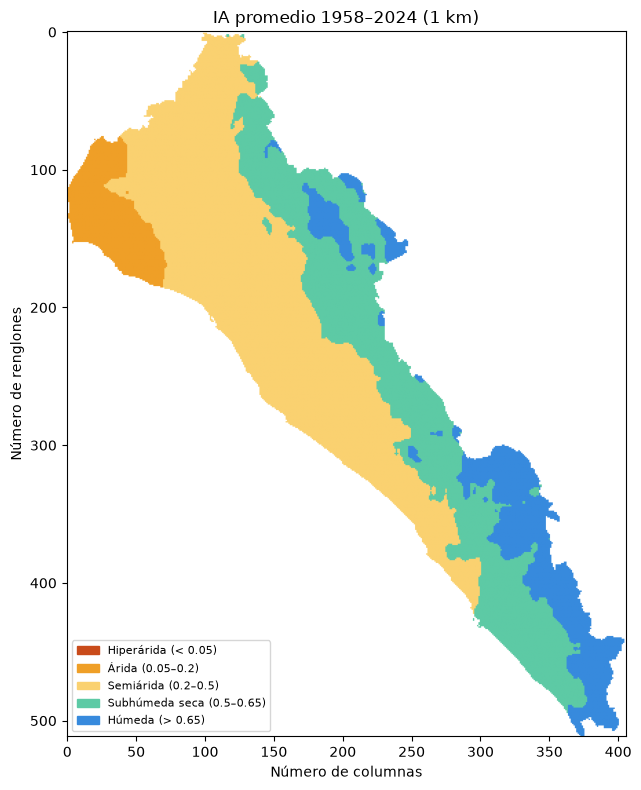

IA promedio 1958-2024 (1 km)
Hiperárida (< 0.05)            0.0 %
Árida (0.05–0.2)               7.2 %
Semiárida (0.2–0.5)           47.1 %
Subhúmeda seca (0.5–0.65)     31.1 %
Húmeda (> 0.65)               14.7 %


In [10]:
FUENTE_GRAFICAS = "1km"      # "1km" | "4km"

G = R1 if (FUENTE_GRAFICAS == "1km" and R1 is not None) else R4
anios_g = G["anios"]
a0, a1 = anios_g[0], anios_g[-1]
print(f"Graficas con la malla de {G['etiqueta']} ({len(anios_g)} años, {a0}-{a1})")

LIMITES = [0, 0.05, 0.20, 0.50, 0.65, 10]
COLORES = ['#c94b1a', '#ef9f27', '#fad170', '#5dcaa5', '#378add']
ETIQUETAS = ['Hiperárida (< 0.05)', 'Árida (0.05–0.2)', 'Semiárida (0.2–0.5)',
             'Subhúmeda seca (0.5–0.65)', 'Húmeda (> 0.65)']
cmap = ListedColormap(COLORES)
norm = BoundaryNorm(LIMITES, cmap.N)


def mapa_ia(ia, titulo, ax=None):
    if ax is None:
        _, ax = plt.subplots(figsize=(7, 8))
    ax.imshow(np.ma.masked_equal(ia, NODATA), cmap=cmap, norm=norm)
    ax.set_title(titulo)
    ax.set_xlabel("Número de columnas")
    ax.set_ylabel("Número de renglones")
    ax.legend(handles=[Patch(color=c, label=e) for c, e in zip(COLORES, ETIQUETAS)],
              loc='lower left', fontsize=8)


def tabla_clases(ia):
    v = ia[ia != NODATA]
    clase = np.digitize(v, LIMITES[1:-1])      # 0..4
    for i, e in enumerate(ETIQUETAS):
        print(f"{e:<28} {100 * np.mean(clase == i):5.1f} %")


fig, ax = plt.subplots(figsize=(7, 8))
mapa_ia(G["prom"], f"IA promedio {a0}–{a1} ({G['etiqueta']})", ax)
plt.tight_layout()
plt.show()

print(f"IA promedio {a0}-{a1} ({G['etiqueta']})")
tabla_clases(G["prom"])

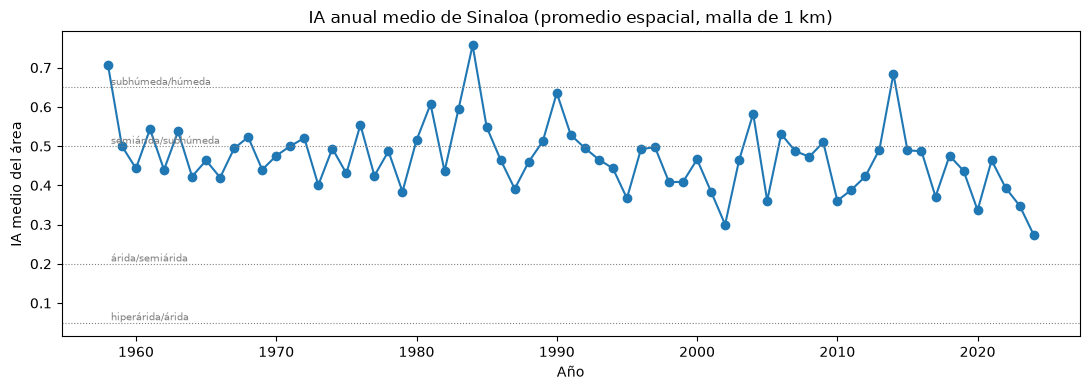

In [11]:
# Serie del IA medio del area por año, con los limites UNEP como referencia
serie = [np.nanmean(p) for p in G["pila_ia"]]
fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(anios_g, serie, marker='o', lw=1.5)
for lim, nombre in zip(LIMITES[1:-1], ['hiperárida/árida', 'árida/semiárida', 'semiárida/subhúmeda', 'subhúmeda/húmeda']):
    ax.axhline(lim, color='gray', ls=':', lw=0.8)
    ax.text(anios_g[0], lim, f" {nombre}", fontsize=7, va='bottom', color='gray')
ax.set_xlabel("Año"); ax.set_ylabel("IA medio del área")
ax.set_title(f"IA anual medio de Sinaloa (promedio espacial, malla de {G['etiqueta']})")
plt.tight_layout(); plt.show()

### Explorar año por año (interactivo)

In [12]:
# !pip install ipywidgets
import ipywidgets as widgets

def ver_anio(anio):
    ia, _ = leer(os.path.join(G["carpeta"], f"IA_anual_{anio}.tif"))
    ia = np.where(np.isfinite(ia), ia, NODATA)
    mapa_ia(ia, f"IA anual {anio} ({G['etiqueta']})")
    plt.show()
    tabla_clases(ia)

widgets.interact(ver_anio, anio=widgets.SelectionSlider(options=anios_g, value=anios_g[-1], description='Año'))

interactive(children=(SelectionSlider(description='Año', index=66, options=(1958, 1959, 1960, 1961, 1962, 1963…

<function __main__.ver_anio(anio)>

### Exportar a vector (1 km): clases y colores, todos los años
Genera **un solo GeoPackage** (`indice_aridez_anual/vectores/IA_1km_<min>_<max>.gpkg`) con todos los años:
- **`celdas`**: un polígono por píxel de 1 km. Columnas `x`, `y` (centroide) y, para el promedio (`prom`) y para **cada año**: `ia_<año>` (valor continuo), `cl_<año>` (clase 0–4) y `co_<año>` (color hex). Una fila por píxel con todos los años en columnas: es la tabla para **probar modelos de clasificación**.
- **`regiones_promedio`** y **`regiones_<año>`**: polígonos de celdas contiguas de la misma clase (`clase_id`, `clase`, `color_hex`, `area_km2`), uno por mapa. Sirven para mapas.

Clases: 0 hiperárida, 1 árida, 2 semiárida, 3 subhúmeda seca, 4 húmeda; −1 = sin dato (color gris).

En QGIS, para usar los colores: Simbología → Relleno → Color → *Anulación definida por datos* → campo `color_hex` (en `regiones_*`) o `co_<año>` (en `celdas`).
Los vectores salen de los GeoTIFF de 1 km, que ya son un remuestreo de 4 km; para entrenar modelos, la malla de 4 km sigue siendo la fuente real de información.

In [14]:
VECTORIZAR       = True
FORMATO_VECTOR   = "shp"      # "gpkg" (un archivo con todas las capas) | "shp" (un archivo por capa; limite de 254 columnas)
REGIONES_ANUALES = True        # True = una capa de regiones por cada año

import geopandas as gpd
from rasterio.features import shapes
from shapely.geometry import shape as shp_shape, box as shp_box

NOMBRES_CLASE = ['Hiperárida', 'Árida', 'Semiárida', 'Subhúmeda seca', 'Húmeda']
COLOR_SIN_DATO = '#808080'
DIR_VEC = os.path.join(RUTA_SALIDA, "vectores")


def clasificar_ia(ia):
    '''Clase UNEP 0-4 por pixel (255 = sin dato). Acepta NaN o NODATA como sin dato.'''
    ok = np.isfinite(ia) & (ia != NODATA)
    clase = np.full(ia.shape, 255, dtype='uint8')
    clase[ok] = np.digitize(ia[ok], LIMITES[1:-1])
    return clase, ok


def regiones(ia, meta):
    '''Poligonos de celdas contiguas de la misma clase.'''
    clase, ok = clasificar_ia(ia)
    regs = list(shapes(clase, mask=ok, transform=meta["transform"], connectivity=4))
    g = gpd.GeoDataFrame({"clase_id": [int(v) for _, v in regs]},
                         geometry=[shp_shape(geom) for geom, _ in regs], crs=meta["crs"])
    g["clase"] = g["clase_id"].map(dict(enumerate(NOMBRES_CLASE)))
    g["color_hex"] = g["clase_id"].map(dict(enumerate(COLORES)))
    g["area_km2"] = g.geometry.area / 1e6
    return g


def celdas_todos_los_anios(R):
    '''Un poligono por pixel y, en columnas, el IA / clase / color del promedio y de cada año.'''
    tr, crs = R["meta"]["transform"], R["meta"]["crs"]
    mapas = [("prom", R["prom"])] + [(str(a), p) for a, p in zip(R["anios"], R["pila_ia"])]

    ok_any = np.zeros(R["prom"].shape, dtype=bool)
    for _, ia in mapas:
        ok_any |= clasificar_ia(ia)[1]
    filas, cols = np.nonzero(ok_any)

    x0 = tr.c + tr.a * cols;  x1 = x0 + tr.a
    y0 = tr.f + tr.e * filas; y1 = y0 + tr.e                      # tr.e es negativo
    datos = {"x": (x0 + x1) / 2, "y": (y0 + y1) / 2}
    paleta = np.array(COLORES + [COLOR_SIN_DATO])
    for etiqueta, ia in mapas:
        clase, ok = clasificar_ia(ia)
        c = np.where(ok, clase, -1)[filas, cols].astype('int16')
        datos[f"ia_{etiqueta}"] = np.where(ok, ia, np.nan)[filas, cols].astype('float32')
        datos[f"cl_{etiqueta}"] = c
        datos[f"co_{etiqueta}"] = paleta[np.where(c >= 0, c, len(COLORES))]
    geoms = [shp_box(min(xa, xb), min(ya, yb), max(xa, xb), max(ya, yb))
             for xa, xb, ya, yb in zip(x0, x1, y0, y1)]
    return gpd.GeoDataFrame(datos, geometry=geoms, crs=crs)


def guardar_vector(capas, nombre):
    os.makedirs(DIR_VEC, exist_ok=True)
    ruta_gpkg = os.path.join(DIR_VEC, f"{nombre}.gpkg")
    if FORMATO_VECTOR == "gpkg" and os.path.exists(ruta_gpkg):
        os.remove(ruta_gpkg)                                      # evita mezclar capas de una corrida anterior
    for capa, gdf in capas.items():
        if FORMATO_VECTOR == "gpkg":
            gdf.to_file(ruta_gpkg, layer=capa, driver="GPKG")
        elif len(gdf.columns) - 1 > 254:
            print(f"Capa '{capa}' omitida: {len(gdf.columns) - 1} columnas superan el limite de .shp (usa 'gpkg').")
        else:
            gdf.to_file(os.path.join(DIR_VEC, f"{nombre}_{capa}.shp"))
    print(f"Vector guardado: {nombre} | {len(capas)} capas | celdas: {len(capas['celdas'])}")


if VECTORIZAR and R1 is None:
    print("No hay mapas de 1 km: genera primero el 1 km (GENERAR_1KM = True).")
elif VECTORIZAR:
    a0_1, a1_1 = R1["anios"][0], R1["anios"][-1]
    capas = {"celdas": celdas_todos_los_anios(R1),
             "regiones_promedio": regiones(R1["prom"], R1["meta"])}
    if REGIONES_ANUALES:
        for anio, pila in zip(R1["anios"], R1["pila_ia"]):
            capas[f"regiones_{anio}"] = regiones(pila, R1["meta"])
    guardar_vector(capas, f"IA_1km_{a0_1}_{a1_1}")
    print(f"Años incluidos: {len(R1['anios'])} ({a0_1}-{a1_1})")

Vector guardado: IA_1km_1958_2024 | 69 capas | celdas: 57432
Años incluidos: 67 (1958-2024)
